# Day 1 - Deliverable 2: NumPy Gradient Descent Engine
**Objective:** Build the mathematical optimization engine from scratch to understand how a machine "learns" parameters. We must maintain strict algorithmic precision here; a single incorrect sign or transposed matrix will throw off the cost calculation, similar to verifying path costs in custom Python search algorithms to ensure they evaluate to exactly 6.

### 1. Synthetic Dataset & Dot Product
We create a tiny dataset and verify the dot product computation manually before trusting the library.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tiny Synthetic Dataset
# 3 observations, 2 features
X = np.array([[1.0, 2.0], 
              [2.0, 3.0], 
              [3.0, 4.0]])
# Target continuous variable
y = np.array([5.0, 8.0, 11.0]) 

# 2. Manual Dot Product vs NumPy
w = np.array([1.5, 1.0]) # Initial arbitrary weight vector

# Manual calculation for the first observation: (1.0 * 1.5) + (2.0 * 1.0) = 3.5
manual_pred = (X[0][0] * w[0]) + (X[0][1] * w[1])

# NumPy calculation for the first observation
numpy_pred = np.dot(X[0], w)

print(f"Manual prediction for Obs 1: {manual_pred}")
print(f"NumPy prediction for Obs 1:  {numpy_pred}")
assert manual_pred == numpy_pred, "Dot product logic failed."

Manual prediction for Obs 1: 3.5
NumPy prediction for Obs 1:  3.5


### 2. Loss Calculation & One Manual Update
The objective of linear regression is to minimize the cost function, often calculated as the Mean Squared Error. The formula is $J(X, y, \theta) = \frac{1}{m} \sum_{i=1}^m (X\cdot\theta - y_i)^2$. 

The gradient descent update rule uses the gradient of the cost function to adjust weights iteratively: $\theta := \theta - \alpha \frac{1}{m} X^T \cdot (X\cdot\theta - y)$.

In [35]:
# 3. Simple Loss Calculation (Mean Squared Error)
def compute_mse_loss(X, y, weights):
    m = len(y)
    predictions = np.dot(X, weights)
    # Compute mean square error
    cost = (1/m) * np.sum(np.square(predictions - y)) 
    return cost

initial_loss = compute_mse_loss(X, y, w)
print(f"Initial Loss: {initial_loss}")

# 4. One Manual Gradient-Descent Update
alpha = 0.01 # Learning rate
m = len(y)

# Step A: Compute predictions
predictions = np.dot(X, w)

# Step B: Compute the error
error = predictions - y

# Step C: Compute the gradient (the steepest slope of the function)
gradient = (1/m) * np.dot(X.T, error) 

# Step D: Update the parameters using the gradient
w_updated = w - (alpha * gradient)

updated_loss = compute_mse_loss(X, y, w_updated)
print(f"Loss after ONE manual update: {updated_loss}")
print(f"Original weights: {w}")
print(f"Updated weights: {w_updated}")

Initial Loss: 4.166666666666666
Loss after ONE manual update: 3.0730185185185204
Original weights: [1.5 1. ]
Updated weights: [1.54333333 1.06333333]


### 3. Optimization Experiments
Now we scale this into a full training loop to perform three experiments:
1. **Change the learning rate:** If the learning rate is too high, we may overshoot the minimum, and if it's too low, convergence takes too long.
2. **Poorly scaled features:** We will observe how unscaled data destabilizes the mathematical gradient.
3. **Constant baseline:** We will compare our learned model against a baseline that simply predicts the mean of $y$ every time.

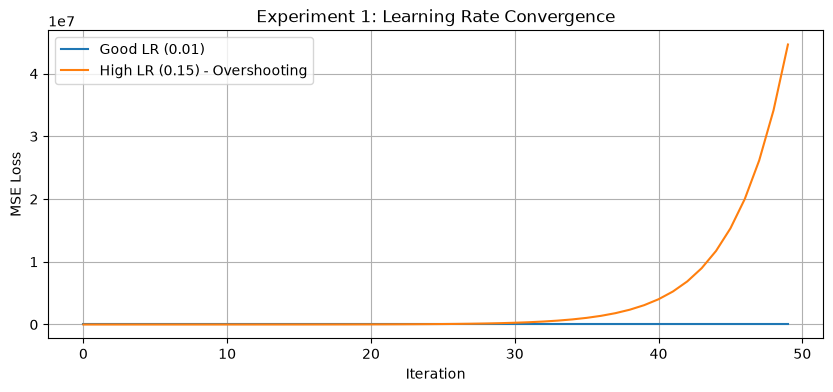

Final Loss with Poor Scaling: inf (Notice the explosion/NaNs)
Baseline (Mean) Loss: 6.0
Our Learned Model Loss: 0.004496918907887244
Decision: Our model successfully beat the constant baseline.


C:\Users\aliab\AppData\Local\Temp\ipykernel_9068\1233273184.py:6: RuntimeWarning: overflow encountered in square
  cost = (1/m) * np.sum(np.square(predictions - y))


In [38]:
def train_model(X_train, y_train, alpha, iterations):
    # Initialize parameters to zeros
    weights = np.zeros(X_train.shape[1]) 
    loss_history = []
    
    for i in range(iterations):
        predictions = np.dot(X_train, weights)
        error = predictions - y_train
        gradient = (1/len(y_train)) * np.dot(X_train.T, error)
        weights = weights - (alpha * gradient)  
        
        loss_history.append(compute_mse_loss(X_train, y_train, weights))
    
    return weights, loss_history

# Experiment 1: Learning Rate Convergence
w_good_lr, loss_good_lr = train_model(X, y, alpha=0.01, iterations=50)
w_high_lr, loss_high_lr = train_model(X, y, alpha=0.15, iterations=50) # Intentionally high

plt.figure(figsize=(10, 4))
plt.plot(loss_good_lr, label='Good LR (0.01)')
plt.plot(loss_high_lr, label='High LR (0.15) - Overshooting')
plt.title('Experiment 1: Learning Rate Convergence')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True) 
plt.show()

# Experiment 2: Poorly Scaled Features
# Creating features with massive numerical differences
X_poor_scale = np.array([[1.0, 2000.0], 
                         [2.0, 3000.0], 
                         [3.0, 4000.0]])
w_poor, loss_poor = train_model(X_poor_scale, y, alpha=0.01, iterations=50)
print(f"Final Loss with Poor Scaling: {loss_poor[-1]} (Notice the explosion/NaNs)")

# Experiment 3: Baseline Comparison
# Baseline: Predict the mean of y for every observation
mean_y = np.mean(y)
baseline_predictions = np.full(shape=y.shape, fill_value=mean_y)
baseline_loss = (1/len(y)) * np.sum(np.square(baseline_predictions - y))

print(f"Baseline (Mean) Loss: {baseline_loss}")
print(f"Our Learned Model Loss: {loss_good_lr[-1]}")

if loss_good_lr[-1] < baseline_loss:
    print("Decision: Our model successfully beat the constant baseline.")